<!--- Project Title --->
<span class="dates">Kelompok 4 | UTS Praktikum Pembelajaran Mesin</span><br>
<span class="title-normal">Dataset </span>
<span class="title-highlight">Bank Customer Churn</span><br>
<hr>


# <div class="header1">**Pembagian Tugas**</div>
<div class="explain-box">
    <table>
      <thead>
        <tr>
          <th>No</th>
          <th>Nama</th>
          <th>NPM</th>
          <th>Tugas</th>
        </tr>
      </thead>
      <tbody>
        <tr>
          <td>1</td>
          <td>Nurul Uzratun Nashriyyah</td>
          <td>2208107010030</td>
          <td>Eksplorasi Data (EDA) dan Visualisasi</td>
        </tr>
        <tr>
          <td>2</td>
          <td>Zahra Zafira</td>
          <td>2208107010040</td>
          <td>Preprocessing Data dan Pemilihan Fitur</td>
        </tr>
        <tr>
          <td>3</td>
          <td>Alhusna Hanifah</td>
          <td>2208107010060</td>
          <td>Implementasi Model, Evaluasi dan Analisis Hasil</td>
        </tr>
        <tr>
          <td>4</td>
          <td>Fadli Ahmad Yazid</td>
          <td>2208107010032</td>
          <td>Analisis Regresi</td>
        </tr>
        <tr>
          <td>5</td>
          <td>Rizky Yusmansyah</td>
          <td>2208107010024</td>
          <td>Analisis Regresi</td>
        </tr>
      </tbody>
    </table>
</div>

# **Bank Customer Churn**
---

## 📊 Informasi Dataset: *Banking Customer Churn Prediction Dataset*

### 📁 Sumber Dataset:
Dataset ini berasal dari repositori terbuka dan digunakan secara luas untuk keperluan analisis data dan pembelajaran mesin, khususnya dalam memprediksi *customer churn* (pelanggan yang berhenti menggunakan layanan) pada sektor perbankan. Dataset ini tersedia di berbagai platform seperti Kaggle.

### 🧾 Deskripsi Umum:
Dataset ini berisi informasi tentang nasabah bank, termasuk status apakah nasabah tersebut telah berhenti menjadi pelanggan (*Exited*) atau tidak. Dataset ini cocok digunakan untuk:
- **Analisis eksploratif (EDA)**: Menggali faktor-faktor yang memengaruhi keputusan nasabah untuk berhenti menggunakan layanan bank.
- **Pemodelan prediktif (Machine Learning)**: Membangun model untuk memprediksi nasabah yang berisiko keluar dari bank berdasarkan fitur-fitur yang tersedia.

---

### 🔍 Penjelasan Setiap Fitur:

| Fitur | Penjelasan |
|-------|------------|
| `RowNumber` | Nomor urut dari setiap baris dalam dataset (sebagai identifikasi urutan data). |
| `CustomerId` | ID unik yang diberikan untuk setiap nasabah bank. |
| `Surname` | Nama belakang nasabah. |
| `CreditScore` | Skor kredit nasabah, menunjukkan kelayakan finansial mereka. |
| `Geography` | Lokasi geografis nasabah (misalnya negara: Prancis, Spanyol, Jerman). |
| `Gender` | Jenis kelamin nasabah (Laki-laki/Perempuan). |
| `Age` | Usia nasabah. |
| `Tenure` | Lama waktu (dalam tahun) nasabah menjadi pelanggan di bank. |
| `Balance` | Saldo yang dimiliki nasabah dalam rekeningnya. |
| `NumOfProducts` | Jumlah produk perbankan yang dimiliki nasabah (misalnya: pinjaman, tabungan, kartu kredit). |
| `HasCrCard` | Apakah nasabah memiliki kartu kredit atau tidak (1 = ya, 0 = tidak). |
| `IsActiveMember` | Apakah nasabah merupakan anggota aktif atau tidak (1 = aktif, 0 = tidak aktif). |
| `EstimatedSalary` | Perkiraan gaji atau penghasilan nasabah. |
| `Exited` | Target variabel (label), menunjukkan apakah nasabah keluar dari bank (1 = keluar, 0 = tetap). |

---

### 📦 Ukuran Dataset:
Ukuran dataset standar ini umumnya terdiri dari:
- **Jumlah Baris**: 10.000 data nasabah
- **Jumlah Kolom**: 14 fitur (termasuk target `Exited`)

## **1. 🧰 Import Library**

Mengimpor berbagai library yang diperlukan dalam proses pembuatan model machine learning. Fungsi utamanya meliputi:

- **Pemrosesan teks** menggunakan Sentence Transformers.
- **Pembagian dataset**, **pencarian hyperparameter terbaik**, dan **pra-pemrosesan data**.
- **Pembuatan model klasifikasi** seperti Logistic Regression, Random Forest, dan XGBoost.
- **Penanganan data tidak seimbang** menggunakan SMOTE.
- **Evaluasi performa model** melalui metrik klasifikasi dan confusion matrix.
- **Visualisasi data dan hasil model** menggunakan Matplotlib dan Seaborn.
- **Normalisasi fitur** untuk meningkatkan performa model.

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from optuna.samplers import TPESampler
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import optuna
import pandas as pd
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## **2. 📥 Load Dataset**

Membaca dataset **Churn Modelling** dari file CSV menggunakan `pandas`. Dataset ini akan digunakan sebagai data utama untuk analisis dan pemodelan.


In [ ]:
# Ganti path jika diperlukan
df = pd.read_csv('/content/Churn_Modelling.csv')
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## **3. Exploratory Data Analysis (EDA)**

Analisis ini bertujuan untuk memahami pola dan insight dari data churn nasabah bank sebelum melanjutkan ke tahap pemodelan. Dengan eksplorasi data, kita bisa mengetahui fitur mana yang relevan, apakah datanya seimbang, dan pola-pola awal yang mungkin menunjukkan faktor-faktor penyebab churn.


In [ ]:
# Informasi umum
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
#cek missing value
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


#### 💡 Catatan Penting
- Kolom bertipe `object` (`Surname`, `Geography`, `Gender`) adalah data kategori dan perlu di-*encode* sebelum digunakan dalam model.
- Kolom seperti `RowNumber`, `CustomerId`, dan `Surname` biasanya tidak digunakan untuk prediksi karena tidak memiliki pengaruh terhadap target `Exited`.
- Tidak ada missing value di dataset — semua kolom memiliki 10.000 nilai (✅ bersih), yang membuatnya siap untuk tahap preprocessing lebih lanjut.

In [ ]:
# Statistik deskriptif
df.describe()


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
# cek data duplikat
df.duplicated().sum()

np.int64(0)

### 🧠 Insight Awal
- Sekitar **20.37%** nasabah melakukan churn. Ini menunjukkan bahwa data sedikit **imbalanced**.
- Data bersih tanpa duplikasi dan tidak memiliki outlier ekstrem, sehingga cukup siap untuk tahap berikutnya (preprocessing & modeling).

### Univariate Analysis
#### 🎯 Distribusi Target `Exited`

In [ ]:
df['Exited'].unique()

array([1, 0])

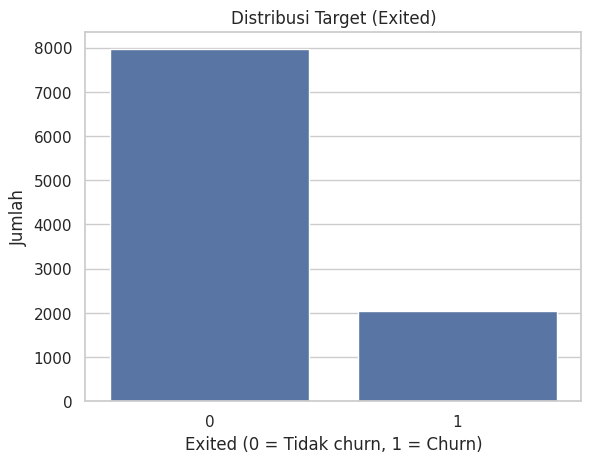

In [ ]:
# Distribusi target
sns.countplot(data=df, x='Exited')
plt.title("Distribusi Target (Exited)")
plt.xlabel("Exited (0 = Tidak churn, 1 = Churn)")
plt.ylabel("Jumlah")
plt.show()


Visualisasi `countplot` pada kolom `Exited` memberikan gambaran:
- Mayoritas nasabah **tidak churn** (Exited = 0)
- Sekitar 20% dari total nasabah melakukan **churn** (Exited = 1)

Artinya, data ini sedikit **imbalanced**, yang bisa menjadi pertimbangan saat membuat model klasifikasi nantinya.


#### 🔢 Kolom Numerik


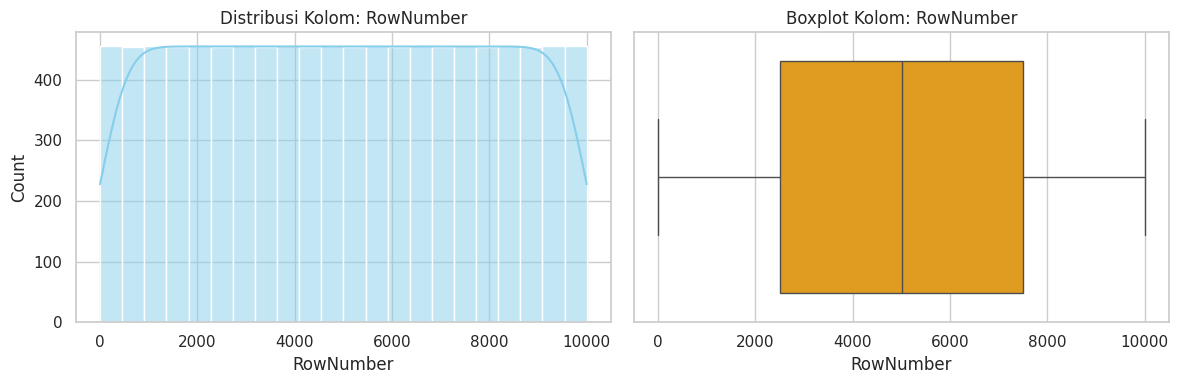

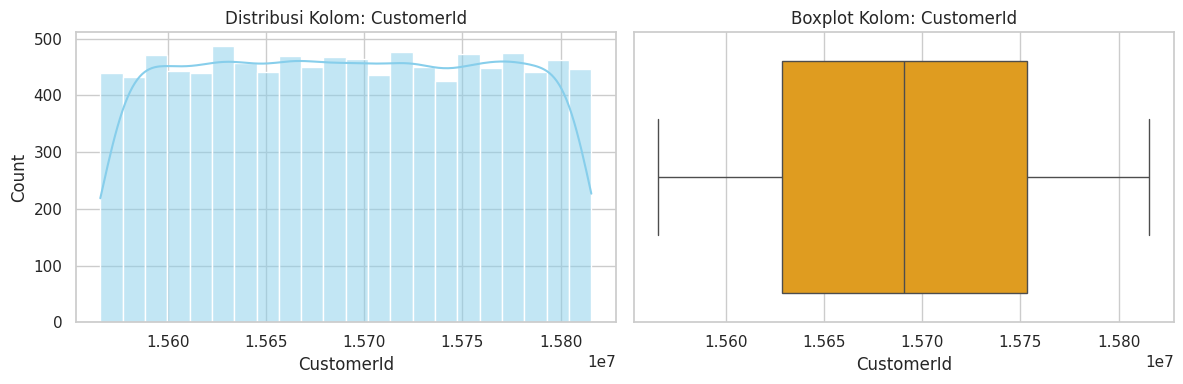

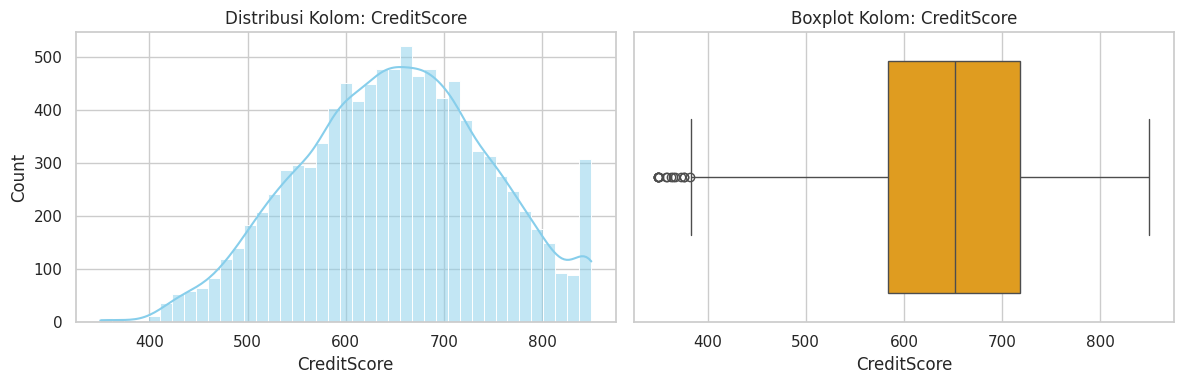

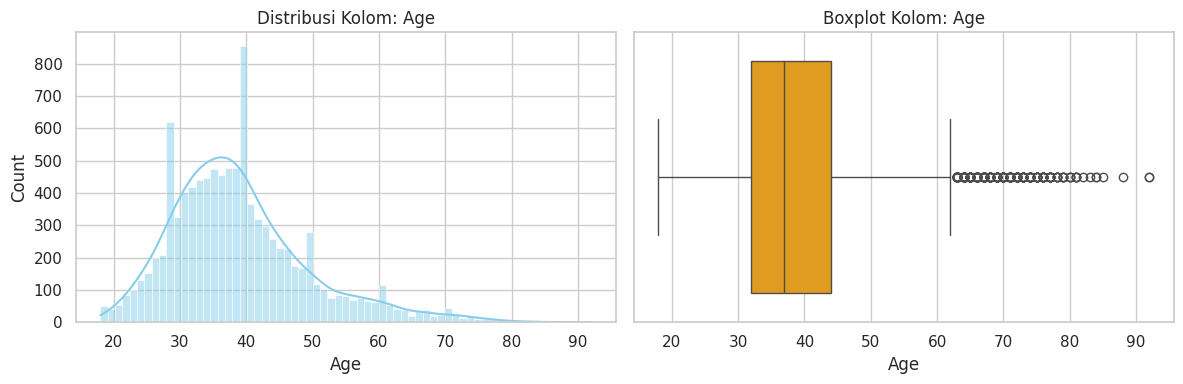

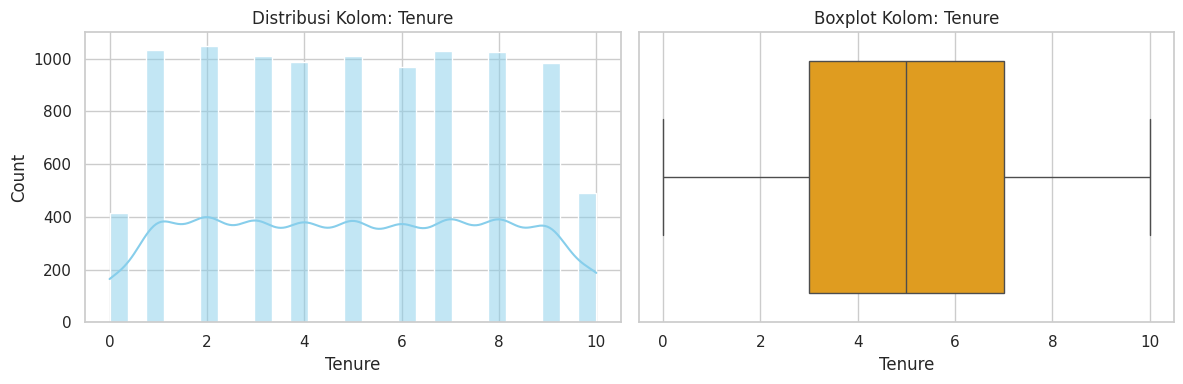

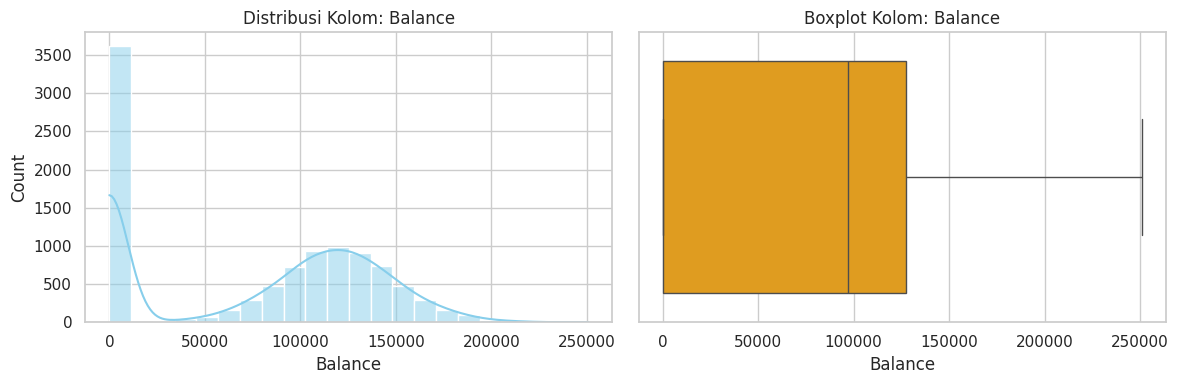

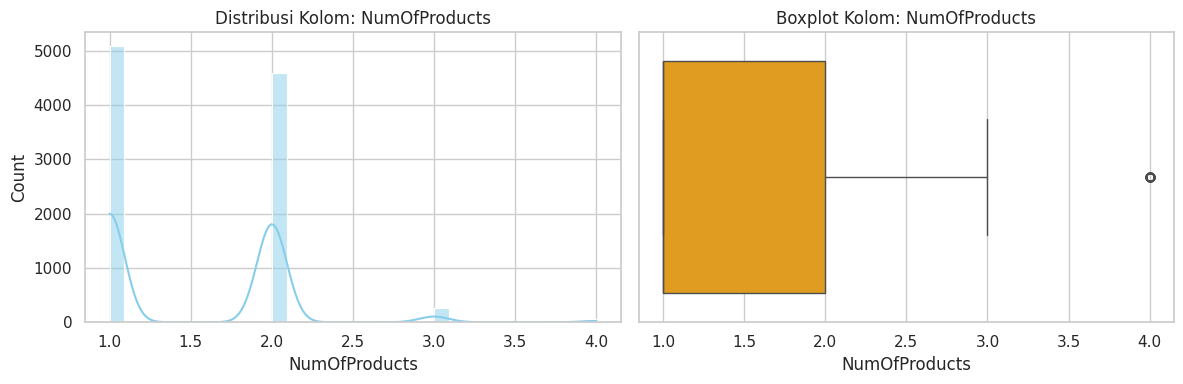

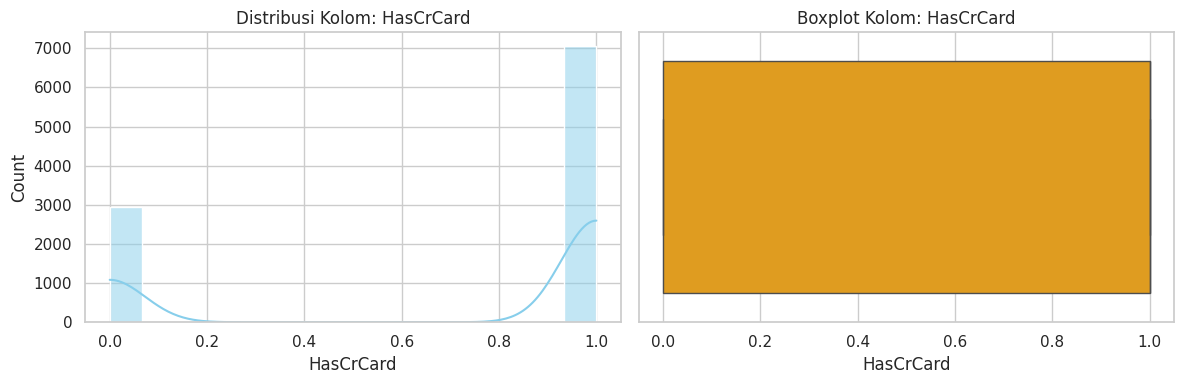

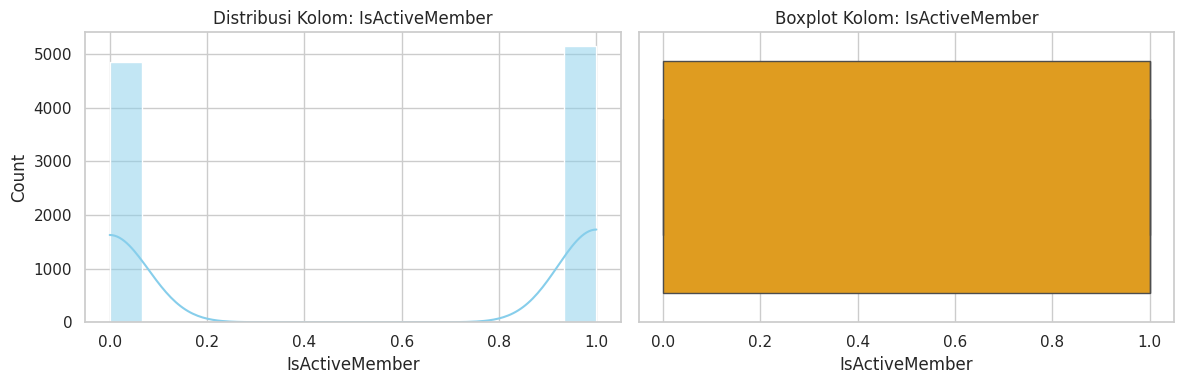

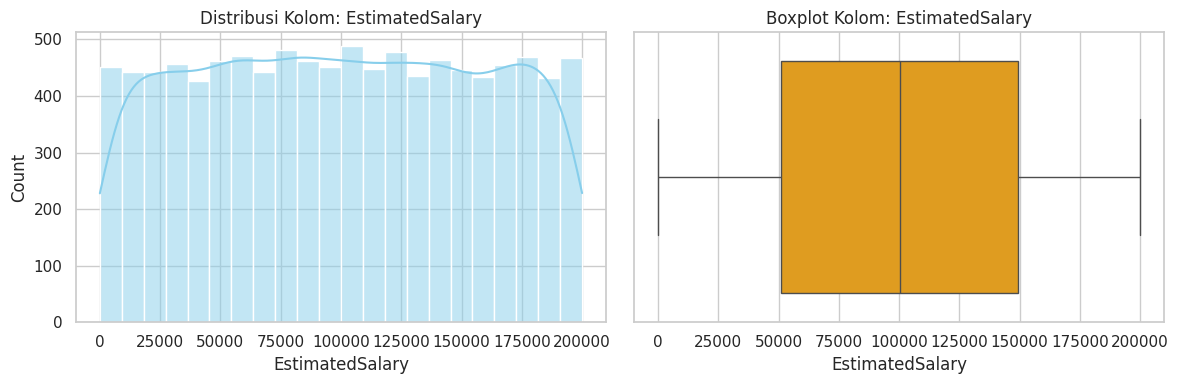

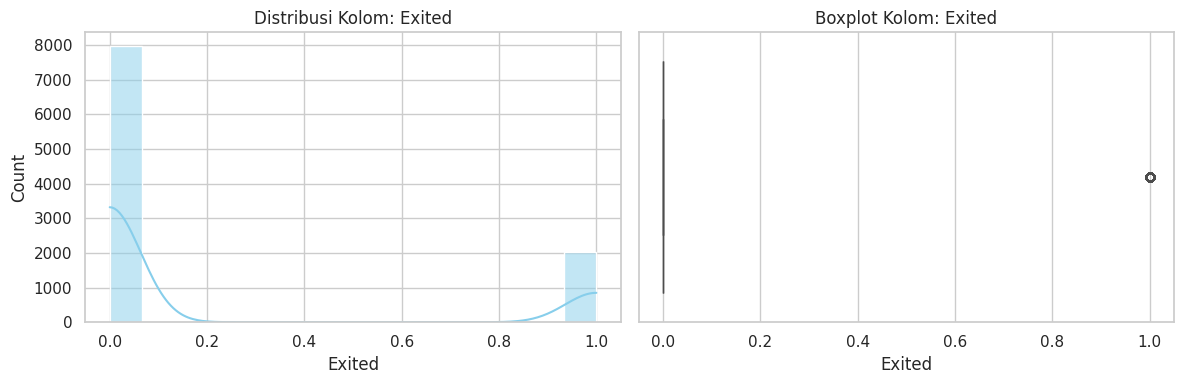

In [ ]:
numerik_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerik_cols:
    plt.figure(figsize=(12, 4))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f"Distribusi Kolom: {col}")

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col], color='orange')
    plt.title(f"Boxplot Kolom: {col}")

    plt.tight_layout()
    plt.show()

📊 Analisis Distribusi dan Boxplot Kolom Numerik

1. Kolom: CreditScore
* Distribusi:

  - Distribusi CreditScore terlihat seperti distribusi normal miring ke kiri (left-skewed).

  - Mayoritas skor berkisar antara 600 hingga 700.

  - Ada puncak aneh di bagian atas sekitar 850

* Boxplot:

  - Terdapat beberapa outlier di sisi bawah (skor kredit rendah).

  - Median skor kredit berada di sekitar 650.

  - Rentang interkuartil lebar

2. Kolom: Age
* Distribusi:

  - Skewed ke kanan (right-skewed), dengan mayoritas data berada di rentang usia 30-40 tahun.

* Boxplot:

  - Median usia sekitar 37-38 tahun.

  - Banyak outlier pada kelompok usia di atas 60 tahun, menunjukkan keberadaan pelanggan yang jauh lebih tua dari mayoritas.

  - Penyebaran cukup luas, dari usia sekitar 18 hingga di atas 90.

3. Kolom: Tenure
* Distribusi:

  - Distribusi Tenure (lama menjadi nasabah) bersifat hampir seragam.

  - Setiap nilai dari 0 hingga 10 tahun memiliki jumlah pelanggan yang hampir sama.

* Boxplot:

  - Median tenure sekitar 5 tahun.

  - Tidak ada outlier yang signifikan.

  - Penyebaran merata.

4. Kolom: Balance
* Distribusi:

  - Ada puncak tinggi di sekitar saldo 0, kemungkinan karena banyak pelanggan tidak memiliki saldo.

  - Puncak kedua terlihat di sekitar 120.000.

* Boxplot:

  - Tidak terlihat outlier signifikan.

  - Median saldo berada di bawah 100.000.

  - Penyebaran nilai cukup luas, dari 0 hingga mendekati 250.000.

5. Kolom: NumOfProducts
* Distribusi:

  - Distribusi bersifat diskrit dan dominan di nilai 1 dan 2 produk.

  - Sedikit pelanggan yang memiliki 3 produk, dan sangat sedikit yang memiliki 4 produk.

* Boxplot:

  - Median berada di sekitar 2 produk.

  - Nilai 4 terdeteksi sebagai outlier.

  - Sebagian besar pelanggan memiliki 1-2 produk, menunjukkan distribusi yang tidak merata.

6. Kolom: HasCrCard
* Distribusi:

  - Kolom ini merupakan data biner (0 = tidak memiliki kartu kredit, 1 = memiliki).

  - Mayoritas pelanggan memiliki kartu kredit (nilai 1), sedangkan sebagian kecil tidak memilikinya.

* Boxplot:

  - Tidak menunjukkan outlier.

  - Boxplot menampilkan distribusi penuh dari 0 ke 1.

7. Kolom: EstimatedSalary
* Distribusi:

  - Distribusi terlihat mendekati seragam dari 0 hingga 200.000.

  - Tidak ada puncak (peak) yang menonjol, menunjukkan nilai gaji tersebar merata di seluruh rentang.

* Boxplot:
  - Rentang nilai menyebar luas tanpa outlier yang mencolok.

  - Median berada di sekitar pertengahan (sekitar 100.000).

  - Data cukup simetris dengan persebaran yang merata.

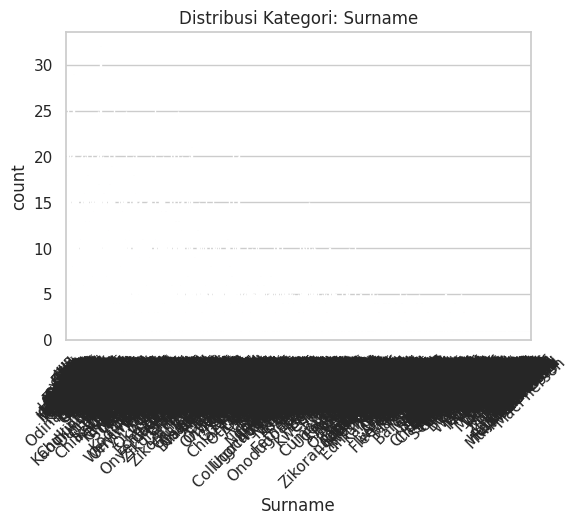

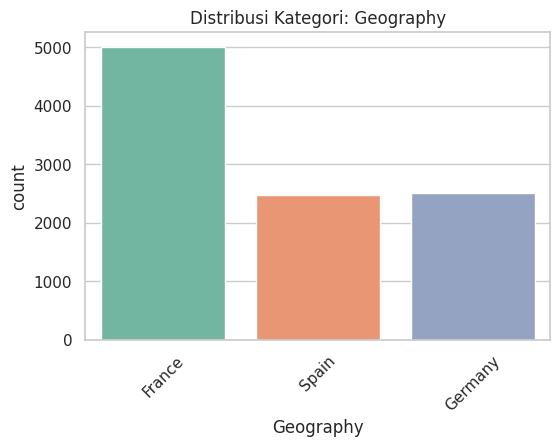

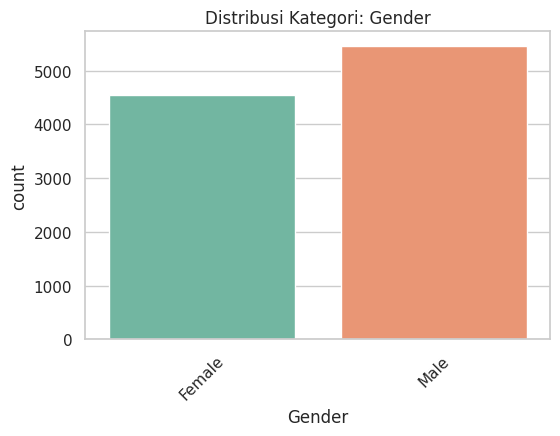

In [ ]:
kategori_cols = df.select_dtypes(include='object').columns

for col in kategori_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, palette='Set2')
    plt.title(f"Distribusi Kategori: {col}")
    plt.xticks(rotation=45)
    plt.show()


📊 Analisis Distribusi dan Boxplot Kolom Kategori

1. Kolom: Geography
* Terdiri dari 3 kategori: France, Spain, dan Germany.

* Distribusi:

  - France mendominasi (~50% data).

  - Spain dan Germany memiliki jumlah yang hampir seimbang dan lebih rendah dari France.

2. Kolom: Gender
* Terdiri dari dua kategori: Female dan Male.

* Distribusi cukup seimbang:

  - Male sedikit lebih banyak daripada Female.

### Multivariate Analysis

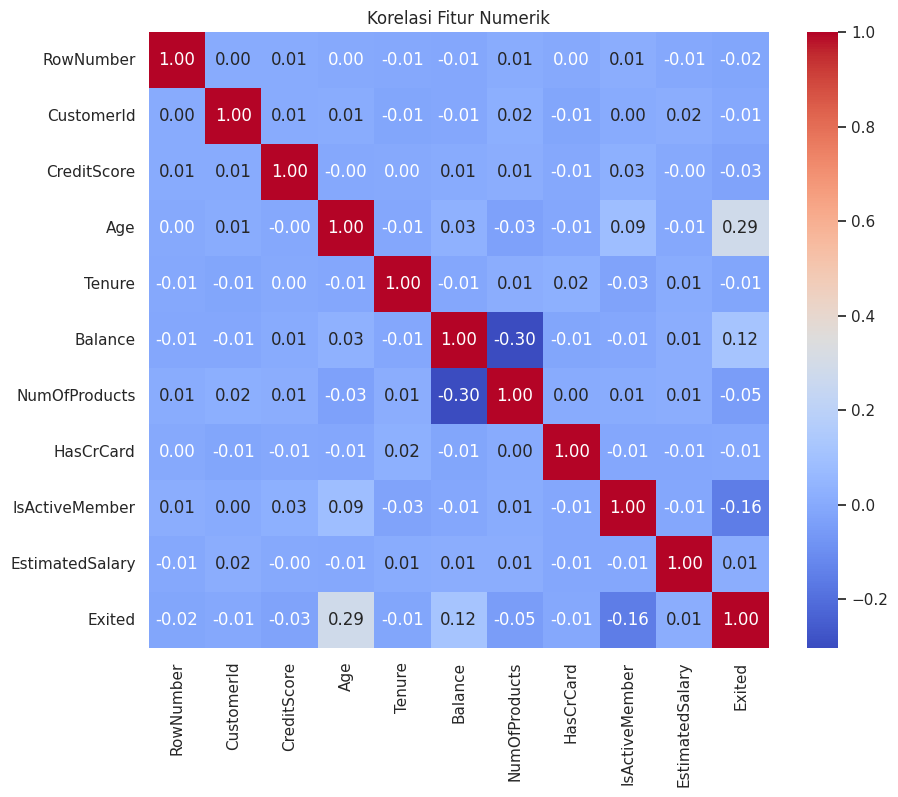

In [ ]:
# Korelasi antar fitur numerik
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['int64', 'float64'])  # ambil kolom numerik
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Korelasi Fitur Numerik")
plt.show()


### 🔥 Heatmap Korelasi Antar Fitur Numerik

Heatmap di atas menggambarkan **hubungan korelasi antar fitur numerik** dalam dataset. Nilai korelasi berkisar antara -1 hingga 1:

- 🔴 **Mendekati +1**: Korelasi positif kuat (fitur naik bersama-sama)
- 🔵 **Mendekati -1**: Korelasi negatif kuat (fitur berlawanan arah)
- ⚪ **Mendekati 0**: Tidak ada korelasi linear yang signifikan

#### 📌 Temuan Penting:

- **`Age` vs `Exited`:** Memiliki korelasi positif moderat sebesar **0.29**, menunjukkan bahwa semakin tua pelanggan, semakin besar kemungkinan mereka untuk keluar dari bank.
- **`IsActiveMember` vs `Exited`:** Korelasi negatif sebesar **-0.16**, mengindikasikan bahwa pelanggan aktif cenderung tetap menjadi nasabah.
- **`Balance` vs `Exited`:** Korelasi positif lemah **(0.12)**, artinya nasabah dengan saldo lebih tinggi sedikit lebih mungkin keluar.
- **`NumOfProducts` vs `Balance`:** Korelasi negatif sebesar **-0.30**, mengindikasikan bahwa pelanggan dengan lebih banyak produk justru cenderung memiliki saldo lebih rendah.
- Kolom seperti `RowNumber`, `CustomerId`, dan `Surname` tidak memiliki korelasi signifikan terhadap `Exited`, dan seringkali dapat dihapus pada tahap pemodelan.

#### 🎯 Kesimpulan:
Beberapa fitur seperti `Age`, `IsActiveMember`, dan `Balance` memberikan sinyal awal bahwa mereka dapat menjadi fitur penting dalam proses prediksi churn.


### Bivariate Analysis
#### 👩‍🦰 Distribusi Churn berdasarkan Gender

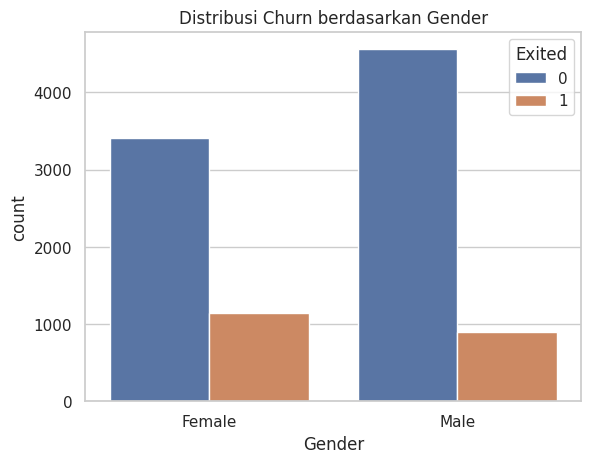

In [ ]:
# Distribusi churn berdasarkan Gender
sns.countplot(data=df, x='Gender', hue='Exited')
plt.title("Distribusi Churn berdasarkan Gender")
plt.show()


#### 📊 Insight yang Didapat:

- **Nasabah Laki-laki (Male)** lebih banyak secara keseluruhan dibandingkan nasabah perempuan.
- Namun, **nasabah perempuan memiliki tingkat churn yang lebih tinggi** dibandingkan laki-laki.

### 🌍 Distribusi Churn berdasarkan Geography

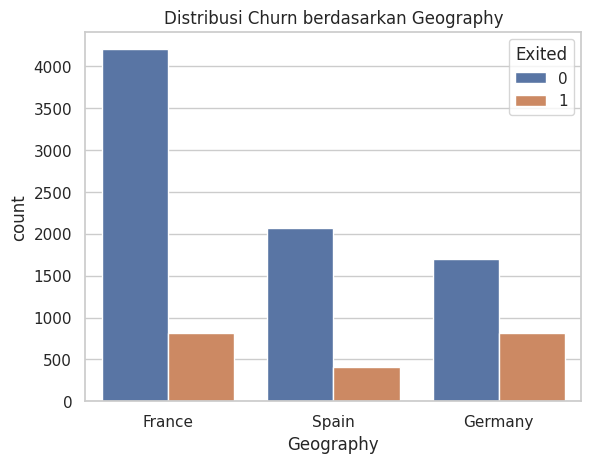

In [ ]:
# Distribusi churn berdasarkan Geography
sns.countplot(data=df, x='Geography', hue='Exited')
plt.title("Distribusi Churn berdasarkan Geography")
plt.show()


#### 📊 Insight yang Didapat:

Plot ini membantu kita memahami pengaruh lokasi geografis:
- Nasabah dari **Germany** dan **France** memiliki tingkat churn yang tinggi dibandingkan Spain.
- Sebaliknya, **nasabah dari Spain** memiliki tingkat churn paling rendah.


## Kesimpulan

- Dataset tidak memiliki missing values dan siap dianalisis lebih lanjut.
- Fitur `Geography`, `Gender`, `Age`, dan `IsActiveMember` tampak memiliki hubungan dengan churn.
- Target sedikit imbalanced, perlu strategi khusus saat pemodelan

Selanjutnya kita bisa melakukan **pembersihan dan encoding data**, lalu masuk ke tahap pemodelan prediktif.

## **4. Data Preprocessing**
Mempersiapkan data untuk digunakan dalam model pembelajaran mesin.


### **Feature Engineering**

Feature engineering merupakan proses penting untuk menyiapkan data sebelum digunakan oleh model. Di tahap ini, fitur-fitur (kolom) dalam dataset diolah agar lebih informatif dan mudah diproses oleh algoritma machine learning.

#### **Menghapus Kolom yang Tidak Relevan**

Menghapus kolom-kolom yang tidak memiliki pengaruh signifikan terhadap proses prediksi, seperti ID unik dan nama pelanggan. Hal ini dilakukan untuk menyederhanakan dataset dan menghindari noise pada model.


In [ ]:
# Hapus kolom 'email'
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

#### **Data Transformation**

1. **Label Encoding pada Kolom 'Gender'**  
   `LabelEncoder` dari `sklearn.preprocessing` digunakan untuk mengubah nilai kategorikal pada kolom **'Gender'** menjadi format numerik. Ini berguna agar model pembelajaran mesin dapat memproses data kategorikal yang berupa teks.

2. **One-Hot Encoding pada Kolom 'Geography'**  
   `pd.get_dummies` digunakan untuk mengubah kolom **'Geography'** yang memiliki nilai kategorikal menjadi beberapa kolom biner (0 atau 1). Pilihan `drop_first=True` digunakan untuk menghindari masalah multikolinearitas dengan menghapus satu kolom hasil encoding.


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode Gender
le_gender = LabelEncoder()
df['Gender'] = le_gender.fit_transform(df['Gender'])
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

In [ ]:
df.head(10)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True
5,645,1,44,8,113755.78,2,1,0,149756.71,1,False,True
6,822,1,50,7,0.00,2,1,1,10062.80,0,False,False
7,376,0,29,4,115046.74,4,1,0,119346.88,1,True,False
8,501,1,44,4,142051.07,2,0,1,74940.50,0,False,False
9,684,1,27,2,134603.88,1,1,1,71725.73,0,False,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Gender             10000 non-null  int64  
 2   Age                10000 non-null  int64  
 3   Tenure             10000 non-null  int64  
 4   Balance            10000 non-null  float64
 5   NumOfProducts      10000 non-null  int64  
 6   HasCrCard          10000 non-null  int64  
 7   IsActiveMember     10000 non-null  int64  
 8   EstimatedSalary    10000 non-null  float64
 9   Exited             10000 non-null  int64  
 10  Geography_Germany  10000 non-null  bool   
 11  Geography_Spain    10000 non-null  bool   
dtypes: bool(2), float64(2), int64(8)
memory usage: 800.9 KB


#### **Feature Selection (Seleksi Fitur)**
- **X** berisi data fitur yang akan digunakan untuk melatih model.
- **y** berisi data target yang akan diprediksi oleh model.

In [ ]:
X=df.drop("Exited",axis=1)
y=df["Exited"]

#### **Handling Imbalanced Data**
**SMOTE** digunakan untuk menyeimbangkan distribusi kelas dalam dataset, dengan meningkatkan jumlah contoh dari kelas minoritas, yang sangat penting dalam algoritma pembelajaran mesin yang sensitif terhadap ketidakseimbangan kelas.

In [ ]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

#### **Feature Scaling**
**StandardScaler** mengubah fitur numerik menjadi distribusi dengan mean = 0 dan standar deviasi = 1.

In [ ]:
# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_smote)

#### **Data Splitting**
Membagi data menjadi **training set** dan **test set**, sehingga model dapat dilatih dengan data pelatihan.

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_smote, test_size=0.2, random_state=42)

## 5. Memilih Model

Metode Klasifikasi yang Digunakan:
1. **XGBoost (Extreme Gradient Boosting)**
2. **Random Forest Classifier**

### **Mengapa?**
###🔸 **1. XGBoost**  
XGBoost adalah algoritma berbasis ensemble **Gradient Boosting** yang dikenal karena **akurasi tinggi, efisiensi, dan kemampuan menangani data tidak seimbang**.  
**Alasan memilih XGBoost:**
- ⚡ **Kinerja Tinggi**: Mampu menghasilkan prediksi yang sangat akurat, cocok untuk dataset dengan fitur kompleks seperti data perbankan.
- 🧮 **Mampu Menangani Missing Value & Outlier**: Tidak sensitif terhadap data yang tidak sempurna.
- 🎯 **Fokus pada Error yang Sulit**: Melatih model baru untuk memperbaiki kesalahan dari model sebelumnya, sehingga sangat efektif untuk prediksi churn (yang umumnya minoritas).
- 🛠️ **Hyperparameter Tuning Fleksibel**: Memungkinkan penyetelan yang detail untuk mengoptimalkan performa.

---

### 🔸 **2. Random Forest Classifier**
Random Forest adalah metode *bagging* yang membangun banyak pohon keputusan dan menggabungkan hasilnya untuk prediksi akhir.  
**Alasan memilih Random Forest:**
- 🌳 **Stabil dan Handal**: Mengurangi overfitting dengan menggabungkan prediksi dari banyak pohon.
- 🧩 **Menangani Data Campuran**: Cocok untuk data tabular yang memiliki fitur numerik dan kategorikal.
- ⚖️ **Resisten terhadap Data Tidak Seimbang**: Performa tetap baik meskipun target `Exited` mungkin tidak seimbang.
- 📊 **Feature Importance**: Memudahkan interpretasi model melalui nilai pentingnya setiap fitur.

---

## 🧾 Kesimpulan:
Kedua metode ini **sangat cocok** digunakan dalam masalah prediksi customer churn karena:
- Dataset bersifat **tabular dengan kombinasi fitur numerik dan kategorikal**.
- Target `Exited` adalah **masalah klasifikasi biner**, cocok untuk algoritma decision tree-based.
- Kedua model mampu menangani **kompleksitas hubungan antar fitur** dan memiliki **akurasi tinggi** dalam berbagai kasus industri, termasuk perbankan.

## **6. Membangun Model**
Pada bagian ini, kita telah membangun model klasifikasi untuk memprediksi nasabah bank yang berpotensi melakukan churn (berhenti menggunakan layanan bank). Proses yang dilakukan meliputi pembuatan model dasar dengan parameter default, optimasi hyperparameter menggunakan berbagai metode, dan evaluasi performa model.

### **6.1 Membangun Model dengan Parameter Default**

In [ ]:
# Inisialisasi model Random Forest dengan parameter default
rf_model = RandomForestClassifier(random_state=42)
# Melatih model Random Forest
rf_model.fit(X_train, y_train)
# Prediksi menggunakan model Random Forest
y_pred_rf = rf_model.predict(X_test)

In [ ]:
# Inisialisasi model XGBoost dengan parameter default
xgb_model = XGBClassifier(random_state=42)
# Melatih model XGBoost
xgb_model.fit(X_train, y_train)
# Prediksi menggunakan model XGBoost
y_pred_xgb = xgb_model.predict(X_test)

EVALUASI MODEL DENGAN PARAMETER DEFAULT
Evaluasi Model Random Forest Default:
Accuracy: 0.8732
Precision: 0.8685
Recall: 0.8719
F1-score: 0.8702

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.87      0.88      1633
           1       0.87      0.87      0.87      1553

    accuracy                           0.87      3186
   macro avg       0.87      0.87      0.87      3186
weighted avg       0.87      0.87      0.87      3186



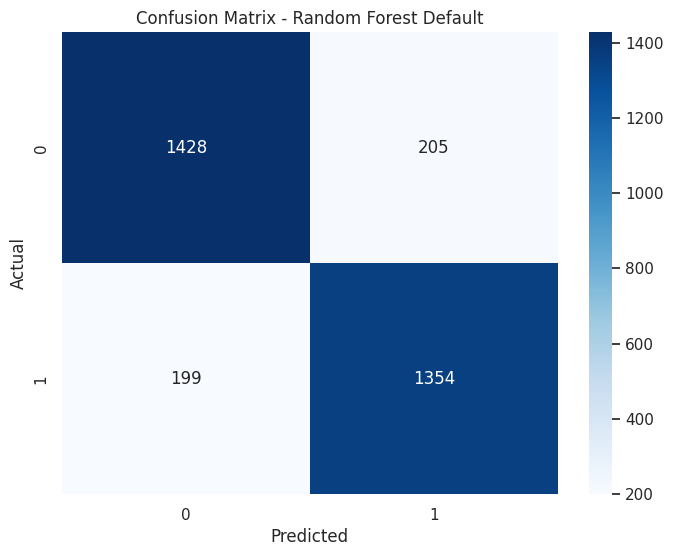



Evaluasi Model XGBoost Default:
Accuracy: 0.8719
Precision: 0.8640
Recall: 0.8751
F1-score: 0.8695

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.87      0.87      1633
           1       0.86      0.88      0.87      1553

    accuracy                           0.87      3186
   macro avg       0.87      0.87      0.87      3186
weighted avg       0.87      0.87      0.87      3186



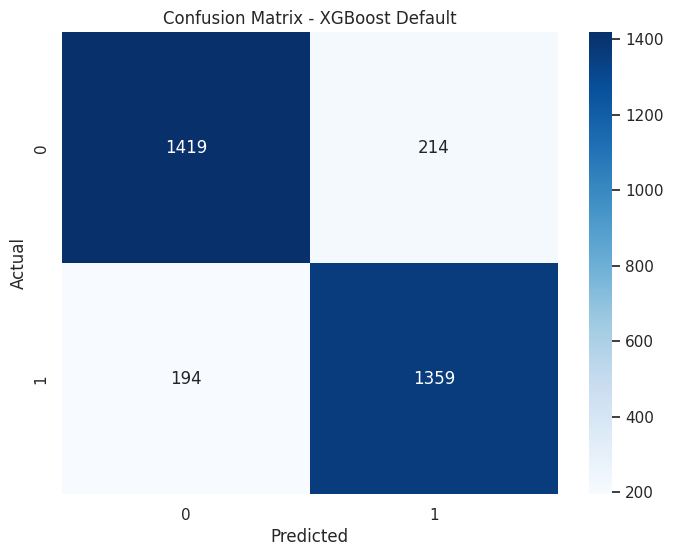

In [ ]:
# Evaluasi model dengan parameter default
def evaluate_model(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"Evaluasi Model {model_name}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    # Confusion Matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return accuracy, precision, recall, f1

# Evaluasi Random Forest dengan parameter default
print("=" * 50)
print("EVALUASI MODEL DENGAN PARAMETER DEFAULT")
print("=" * 50)
rf_default_accuracy, rf_default_precision, rf_default_recall, rf_default_f1 = evaluate_model('Random Forest Default', y_test, y_pred_rf)

# Evaluasi XGBoost dengan parameter default
print("\n")
xgb_default_accuracy, xgb_default_precision, xgb_default_recall, xgb_default_f1 = evaluate_model('XGBoost Default', y_test, y_pred_xgb)

### **6.2 Hyperparameter Tuning dengan GridSearchCV**

HYPERPARAMETER TUNING DENGAN GRIDSEARCHCV
Memulai GridSearchCV untuk Random Forest...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters for Random Forest (GridSearchCV): {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best score: 0.8703
Evaluasi Model Random Forest (GridSearchCV):
Accuracy: 0.8748
Precision: 0.8670
Recall: 0.8777
F1-score: 0.8723

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.87      0.88      1633
           1       0.87      0.88      0.87      1553

    accuracy                           0.87      3186
   macro avg       0.87      0.87      0.87      3186
weighted avg       0.87      0.87      0.87      3186



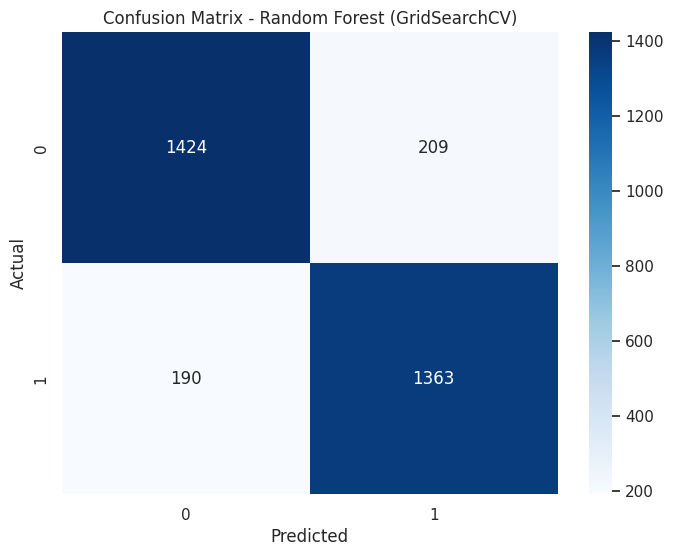

In [ ]:
# GridSearchCV untuk Random Forest
print("=" * 50)
print("HYPERPARAMETER TUNING DENGAN GRIDSEARCHCV")
print("=" * 50)

print("Memulai GridSearchCV untuk Random Forest...")
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    n_jobs=-1,
    scoring='f1',
    verbose=1
)

rf_grid_search.fit(X_train, y_train)
print(f"Best parameters for Random Forest (GridSearchCV): {rf_grid_search.best_params_}")
print(f"Best score: {rf_grid_search.best_score_:.4f}")

# Evaluasi model Random Forest terbaik dari GridSearchCV
rf_best_grid = rf_grid_search.best_estimator_
y_pred_rf_grid = rf_best_grid.predict(X_test)
rf_grid_accuracy, rf_grid_precision, rf_grid_recall, rf_grid_f1 = evaluate_model('Random Forest (GridSearchCV)', y_test, y_pred_rf_grid)


Memulai GridSearchCV untuk XGBoost...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best parameters for XGBoost (GridSearchCV): {'colsample_bytree': 1.0, 'gamma': 0.1, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Best score: 0.8730
Evaluasi Model XGBoost (GridSearchCV):
Accuracy: 0.8823
Precision: 0.8690
Recall: 0.8931
F1-score: 0.8809

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      1633
           1       0.87      0.89      0.88      1553

    accuracy                           0.88      3186
   macro avg       0.88      0.88      0.88      3186
weighted avg       0.88      0.88      0.88      3186



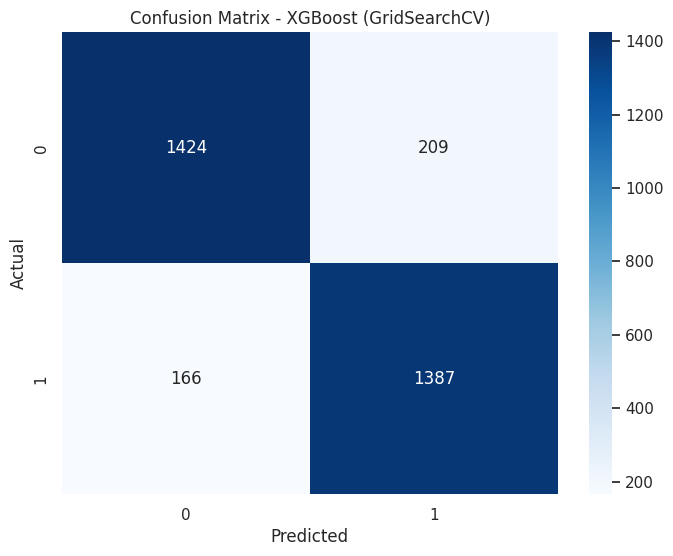

In [ ]:
# GridSearchCV untuk XGBoost
print("\nMemulai GridSearchCV untuk XGBoost...")
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.3]
}

xgb_grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42),
    param_grid=xgb_param_grid,
    cv=5,
    n_jobs=-1,
    scoring='f1',
    verbose=1
)

xgb_grid_search.fit(X_train, y_train)
print(f"Best parameters for XGBoost (GridSearchCV): {xgb_grid_search.best_params_}")
print(f"Best score: {xgb_grid_search.best_score_:.4f}")

# Evaluasi model XGBoost terbaik dari GridSearchCV
xgb_best_grid = xgb_grid_search.best_estimator_
y_pred_xgb_grid = xgb_best_grid.predict(X_test)
xgb_grid_accuracy, xgb_grid_precision, xgb_grid_recall, xgb_grid_f1 = evaluate_model('XGBoost (GridSearchCV)', y_test, y_pred_xgb_grid)

### **6.3 Hyperparameter Tuning dengan RandomizedSearchCV**

HYPERPARAMETER TUNING DENGAN RANDOMIZEDSEARCHCV
Memulai RandomizedSearchCV untuk Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters for Random Forest (RandomizedSearchCV): {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 40, 'class_weight': 'balanced', 'bootstrap': False}
Best score: 0.8689
Evaluasi Model Random Forest (RandomizedSearchCV):
Accuracy: 0.8713
Precision: 0.8671
Recall: 0.8693
F1-score: 0.8682

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.87      0.87      1633
           1       0.87      0.87      0.87      1553

    accuracy                           0.87      3186
   macro avg       0.87      0.87      0.87      3186
weighted avg       0.87      0.87      0.87      3186



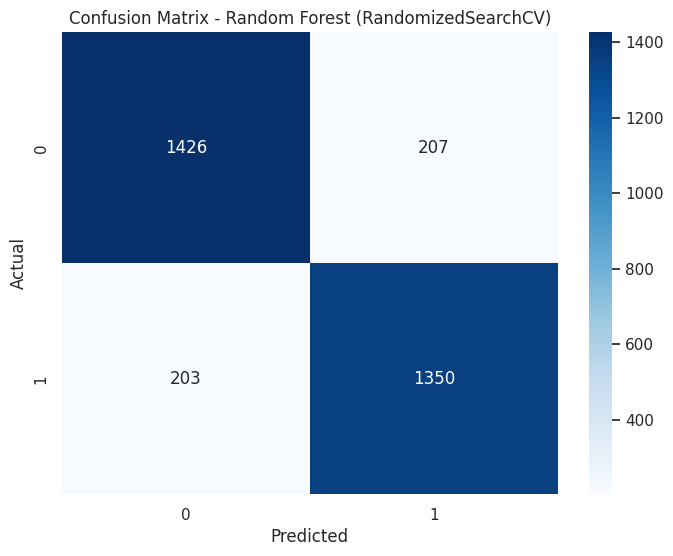

In [ ]:
# RandomizedSearchCV untuk Random Forest
print("=" * 50)
print("HYPERPARAMETER TUNING DENGAN RANDOMIZEDSEARCHCV")
print("=" * 50)

print("Memulai RandomizedSearchCV untuk Random Forest...")
rf_param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
    'class_weight': ['balanced', None]
}

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=30,
    cv=5,
    n_jobs=-1,
    scoring='f1',
    random_state=42,
    verbose=1
)

rf_random_search.fit(X_train, y_train)
print(f"Best parameters for Random Forest (RandomizedSearchCV): {rf_random_search.best_params_}")
print(f"Best score: {rf_random_search.best_score_:.4f}")

# Evaluasi model Random Forest terbaik dari RandomizedSearchCV
rf_best_random = rf_random_search.best_estimator_
y_pred_rf_random = rf_best_random.predict(X_test)
rf_random_accuracy, rf_random_precision, rf_random_recall, rf_random_f1 = evaluate_model('Random Forest (RandomizedSearchCV)', y_test, y_pred_rf_random)


Memulai RandomizedSearchCV untuk XGBoost...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters for XGBoost (RandomizedSearchCV): {'subsample': 0.8, 'scale_pos_weight': 1, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.9}
Best score: 0.8729
Evaluasi Model XGBoost (RandomizedSearchCV):
Accuracy: 0.8823
Precision: 0.8695
Recall: 0.8925
F1-score: 0.8808

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      1633
           1       0.87      0.89      0.88      1553

    accuracy                           0.88      3186
   macro avg       0.88      0.88      0.88      3186
weighted avg       0.88      0.88      0.88      3186



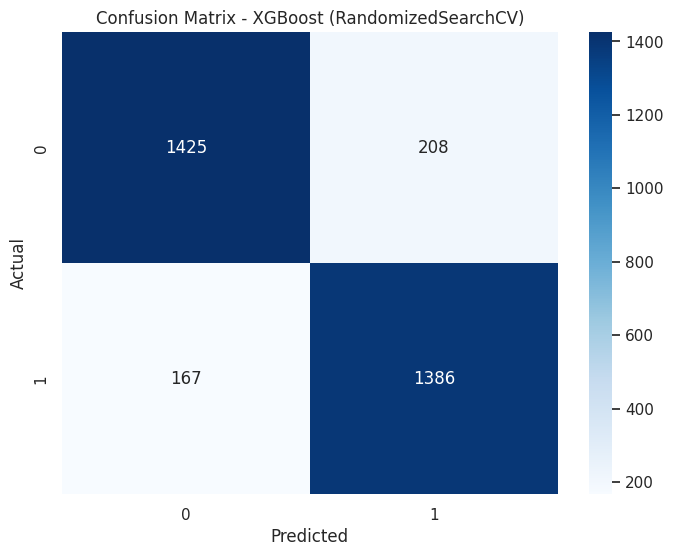

In [ ]:
# RandomizedSearchCV untuk XGBoost
print("\nMemulai RandomizedSearchCV untuk XGBoost...")
xgb_param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 5, 7, 9, 11],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5, 1],
    'min_child_weight': [1, 3, 5, 7],
    'scale_pos_weight': [1, 2, 3]
}

xgb_random_search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42),
    param_distributions=xgb_param_dist,
    n_iter=30,
    cv=5,
    n_jobs=-1,
    scoring='f1',
    random_state=42,
    verbose=1
)

xgb_random_search.fit(X_train, y_train)
print(f"Best parameters for XGBoost (RandomizedSearchCV): {xgb_random_search.best_params_}")
print(f"Best score: {xgb_random_search.best_score_:.4f}")

# Evaluasi model XGBoost terbaik dari RandomizedSearchCV
xgb_best_random = xgb_random_search.best_estimator_
y_pred_xgb_random = xgb_best_random.predict(X_test)
xgb_random_accuracy, xgb_random_precision, xgb_random_recall, xgb_random_f1 = evaluate_model('XGBoost (RandomizedSearchCV)', y_test, y_pred_xgb_random)

### **6.4 Hyperparameter Tuning dengan Optuna**

[I 2025-04-22 16:01:12,500] A new study created in memory with name: no-name-6de310bb-ae80-4d41-a9ff-5049b4d08fd2


HYPERPARAMETER TUNING DENGAN OPTUNA
Memulai Optuna untuk Random Forest...


[I 2025-04-22 16:01:27,655] Trial 0 finished with value: 0.8599165824974996 and parameters: {'n_estimators': 250, 'max_depth': 29, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8599165824974996.
[I 2025-04-22 16:02:58,367] Trial 1 finished with value: 0.8645017811519653 and parameters: {'n_estimators': 488, 'max_depth': 26, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': True, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.8645017811519653.
[I 2025-04-22 16:03:55,849] Trial 2 finished with value: 0.8126186877529002 and parameters: {'n_estimators': 217, 'max_depth': 14, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': None, 'bootstrap': False, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.8645017811519653.
[I 2025-04-22 16:04:38,097] Trial 3 finished with value: 0.8652921543191422 and parameters: {'n_estimators': 

Best parameters for Random Forest (Optuna): {'n_estimators': 279, 'max_depth': 19, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': False, 'class_weight': None}
Best score: 0.8685
Evaluasi Model Random Forest (Optuna):
Accuracy: 0.8748
Precision: 0.8713
Recall: 0.8719
F1-score: 0.8716

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      1633
           1       0.87      0.87      0.87      1553

    accuracy                           0.87      3186
   macro avg       0.87      0.87      0.87      3186
weighted avg       0.87      0.87      0.87      3186



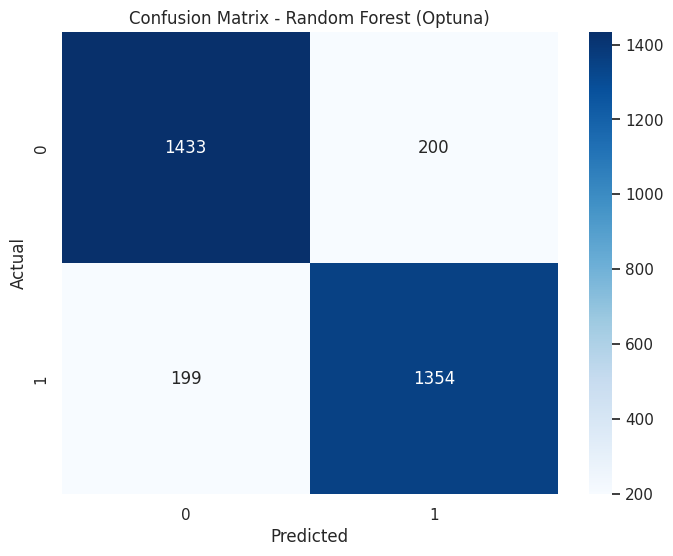

In [ ]:
print("=" * 50)
print("HYPERPARAMETER TUNING DENGAN OPTUNA")
print("=" * 50)

# Optuna untuk Random Forest
print("Memulai Optuna untuk Random Forest...")

def objective_rf(trial):
    # Parameter untuk Random Forest
    rf_params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', None]),
    }

    # Buat model dengan parameter yang disarankan
    rf_model = RandomForestClassifier(**rf_params, random_state=42)

    # Cross-validation
    from sklearn.model_selection import cross_val_score
    scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='f1')

    return scores.mean()

# Buat studi Optuna untuk Random Forest
study_rf = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_rf.optimize(objective_rf, n_trials=30)

# Dapatkan parameter terbaik dan buat model final
print(f"Best parameters for Random Forest (Optuna): {study_rf.best_params}")
print(f"Best score: {study_rf.best_value:.4f}")

rf_best_optuna = RandomForestClassifier(**study_rf.best_params, random_state=42)
rf_best_optuna.fit(X_train, y_train)
y_pred_rf_optuna = rf_best_optuna.predict(X_test)
rf_optuna_accuracy, rf_optuna_precision, rf_optuna_recall, rf_optuna_f1 = evaluate_model('Random Forest (Optuna)', y_test, y_pred_rf_optuna)

[I 2025-04-22 16:19:08,955] A new study created in memory with name: no-name-08fe979f-a4d3-4a5f-b9d7-3541f64829a7



Memulai Optuna untuk XGBoost...


[I 2025-04-22 16:19:13,314] Trial 0 finished with value: 0.8782625963270083 and parameters: {'n_estimators': 250, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'gamma': 0.46798356100860794, 'min_child_weight': 1}. Best is trial 0 with value: 0.8782625963270083.
[I 2025-04-22 16:19:15,035] Trial 1 finished with value: 0.860011836954811 and parameters: {'n_estimators': 447, 'max_depth': 9, 'learning_rate': 0.11114989443094977, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9879639408647978, 'gamma': 2.497327922401265, 'min_child_weight': 2}. Best is trial 0 with value: 0.8782625963270083.
[I 2025-04-22 16:19:15,947] Trial 2 finished with value: 0.8448304823162214 and parameters: {'n_estimators': 172, 'max_depth': 4, 'learning_rate': 0.028145092716060652, 'subsample': 0.8099025726528951, 'colsample_bytree': 0.7727780074568463, 'gamma': 0.8736874205941257, 'min_child_weight': 5}. Best is trial 0 with va

Best parameters for XGBoost (Optuna): {'n_estimators': 250, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'gamma': 0.46798356100860794, 'min_child_weight': 1}
Best score: 0.8783
Evaluasi Model XGBoost (Optuna):
Accuracy: 0.8773
Precision: 0.8691
Recall: 0.8809
F1-score: 0.8750

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      1633
           1       0.87      0.88      0.87      1553

    accuracy                           0.88      3186
   macro avg       0.88      0.88      0.88      3186
weighted avg       0.88      0.88      0.88      3186



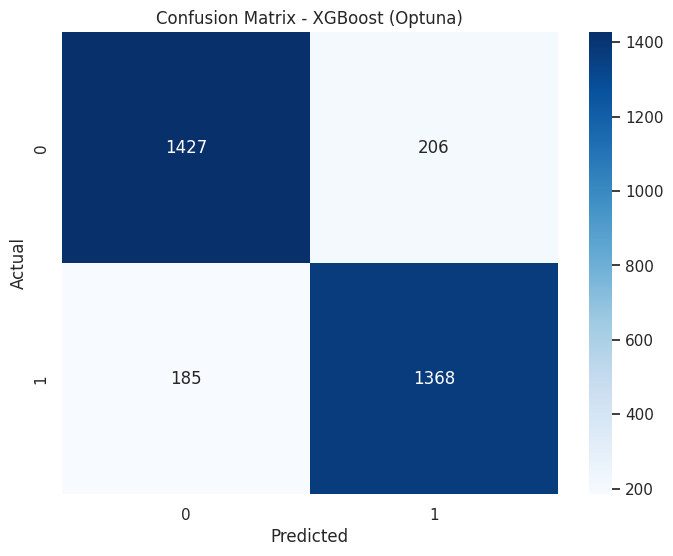

In [ ]:
# Optuna untuk XGBoost
print("\nMemulai Optuna untuk XGBoost...")

def objective_xgb(trial):
    # Parameter untuk XGBoost
    xgb_params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 3),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'random_state': 42,
        'eval_metric': 'logloss'
    }

    # Buat model dengan parameter yang disarankan
    xgb_model = XGBClassifier(**xgb_params)

    # Cross-validation
    scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)

    return scores.mean()

# Buat studi Optuna untuk XGBoost
study_xgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=30)

# Dapatkan parameter terbaik dan buat model final
print(f"Best parameters for XGBoost (Optuna): {study_xgb.best_params}")
print(f"Best score: {study_xgb.best_value:.4f}")

xgb_best_optuna = XGBClassifier(**study_xgb.best_params, random_state=42)
xgb_best_optuna.fit(X_train, y_train)
y_pred_xgb_optuna = xgb_best_optuna.predict(X_test)
xgb_optuna_accuracy, xgb_optuna_precision, xgb_optuna_recall, xgb_optuna_f1 = evaluate_model('XGBoost (Optuna)', y_test, y_pred_xgb_optuna)

## **7. Perbandingan Hasil Evaluasi Model**

In [ ]:
print("=" * 50)
print("PERBANDINGAN HASIL EVALUASI MODEL")
print("=" * 50)

# Menyimpan hasil evaluasi dalam dataframe
results = pd.DataFrame({
    'Model': [
        'Random Forest (Default)',
        'XGBoost (Default)',
        'Random Forest (GridSearchCV)',
        'XGBoost (GridSearchCV)',
        'Random Forest (RandomizedSearchCV)',
        'XGBoost (RandomizedSearchCV)',
        'Random Forest (Optuna)',
        'XGBoost (Optuna)'
    ],
    'Accuracy': [
        rf_default_accuracy,
        xgb_default_accuracy,
        rf_grid_accuracy,
        xgb_grid_accuracy,
        rf_random_accuracy,
        xgb_random_accuracy,
        rf_optuna_accuracy,
        xgb_optuna_accuracy
    ],
    'Precision': [
        rf_default_precision,
        xgb_default_precision,
        rf_grid_precision,
        xgb_grid_precision,
        rf_random_precision,
        xgb_random_precision,
        rf_optuna_precision,
        xgb_optuna_precision
    ],
    'Recall': [
        rf_default_recall,
        xgb_default_recall,
        rf_grid_recall,
        xgb_grid_recall,
        rf_random_recall,
        xgb_random_recall,
        rf_optuna_recall,
        xgb_optuna_recall
    ],
    'F1-Score': [
        rf_default_f1,
        xgb_default_f1,
        rf_grid_f1,
        xgb_grid_f1,
        rf_random_f1,
        xgb_random_f1,
        rf_optuna_f1,
        xgb_optuna_f1
    ]
})

# Menampilkan tabel perbandingan hasil evaluasi
print(results)

PERBANDINGAN HASIL EVALUASI MODEL
                                Model  Accuracy  Precision    Recall  F1-Score
0             Random Forest (Default)  0.873195   0.868505  0.871861  0.870180
1                   XGBoost (Default)  0.871940   0.863954  0.875080  0.869482
2        Random Forest (GridSearchCV)  0.874765   0.867048  0.877656  0.872320
3              XGBoost (GridSearchCV)  0.882298   0.869048  0.893110  0.880915
4  Random Forest (RandomizedSearchCV)  0.871312   0.867052  0.869285  0.868167
5        XGBoost (RandomizedSearchCV)  0.882298   0.869511  0.892466  0.880839
6              Random Forest (Optuna)  0.874765   0.871300  0.871861  0.871580
7                    XGBoost (Optuna)  0.877276   0.869123  0.880876  0.874960


In [ ]:
# Ambil model dengan performa terbaik
best_model_info = results.loc[results['F1-Score'].idxmax()]
best_accuracy = best_model_info['Accuracy']
best_precision = best_model_info['Precision']
best_recall = best_model_info['Recall']
best_f1 = best_model_info['F1-Score']
best_model_name = best_model_info['Model']

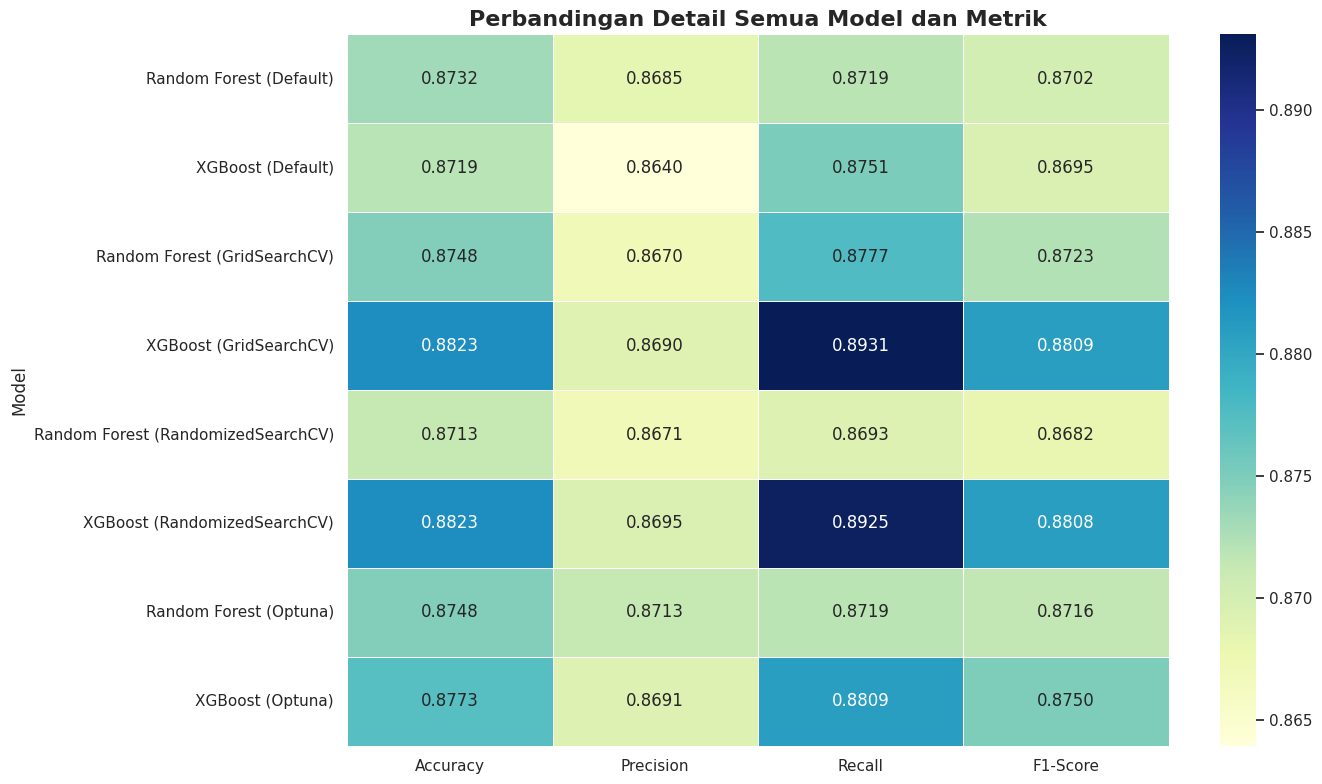

In [ ]:
# Visualisasi perbandingan model secara lebih mendetail
plt.figure(figsize=(14, 8))
sns.heatmap(results.set_index('Model'), annot=True, cmap='YlGnBu', fmt='.4f', linewidths=0.5)
plt.title('Perbandingan Detail Semua Model dan Metrik', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Tampilkan top 3 model terbaik
print("\n" + "=" * 50)
print("TOP 3 MODEL TERBAIK (Berdasarkan F1-Score)")
print("=" * 50)
top_3_models = results.nlargest(3, 'F1-Score')
print(top_3_models.to_string(index=False))


TOP 3 MODEL TERBAIK (Berdasarkan F1-Score)
                       Model  Accuracy  Precision   Recall  F1-Score
      XGBoost (GridSearchCV)  0.882298   0.869048 0.893110  0.880915
XGBoost (RandomizedSearchCV)  0.882298   0.869511 0.892466  0.880839
            XGBoost (Optuna)  0.877276   0.869123 0.880876  0.874960


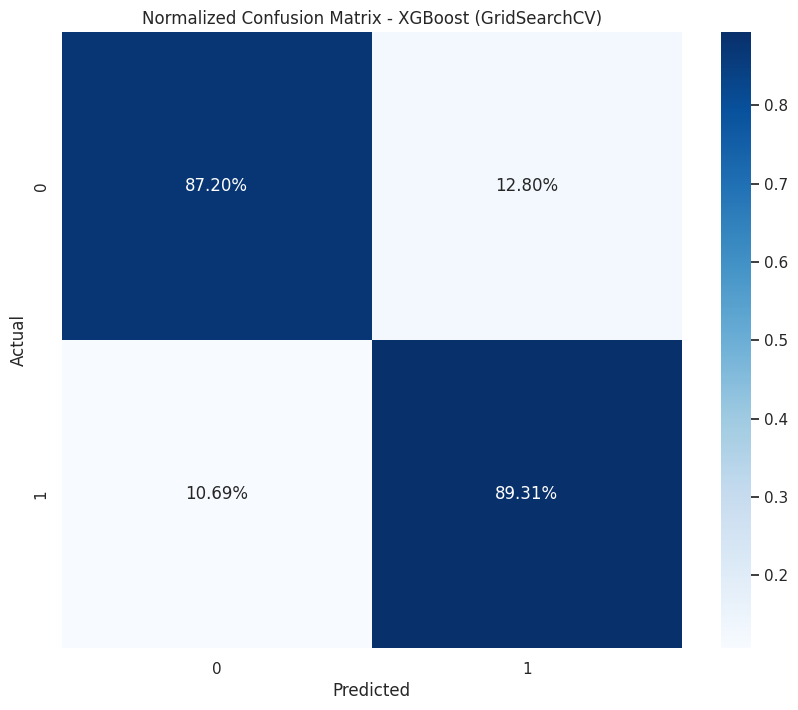

In [ ]:
# Visualisasi confusion matrix model terbaik dengan persentase
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, best_final_model.predict(X_test))
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot confusion matrix dengan persentase
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues')
plt.title(f'Normalized Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

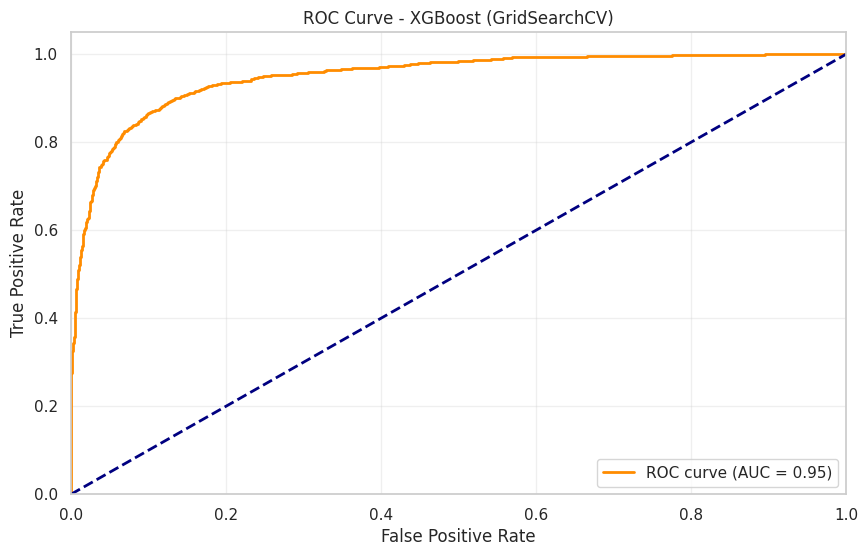

In [ ]:
# ROC Curve untuk model terbaik
from sklearn.metrics import roc_curve, auc

# Dapatkan probabilitas prediksi
y_prob = best_final_model.predict_proba(X_test)[:, 1]

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_model_name}')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()